In [3]:
from glob import glob
from analysis_utlis import *
from other_utlis import *

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### P_app prediction with Hybrid LGFE profiles

#### 1. FCNN

#### 1. A. Is there a better FCNN architecture? 

TLDR : Not really, the archs under this study are not significantly different in performance (using non-parameteric testing) - irrespective of what kind of data spliting strategy used

In [4]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_popc_chol.csv"],
                  ["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_popc_chol_halogen.csv"],
                  ["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_pampa.csv"],
                  ["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_bbb.csv"]]


       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.982025      1.313170
1     butina         RMSE       0.373929      3.287467
2     butina          MAE       0.026216      6.955033
3     butina     PearsonR       0.994171      1.621174
4     butina  SpearmanRho       0.919370      1.854563
5     random           R2       0.702624      1.879564
6     random         RMSE       0.915748      1.285461
7     random          MAE       0.351731      2.216444
8     random     PearsonR       0.989881      1.517934
9     random  SpearmanRho       0.571882      2.621456
10  scaffold           R2       0.004913      5.621458
11  scaffold         RMSE       0.992275      1.307954
12  scaffold          MAE       0.906560      1.547369
13  scaffold     PearsonR       0.046363      4.164976
14  scaffold  SpearmanRho       0.014582      4.906383
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.090151      4.146510
1     buti

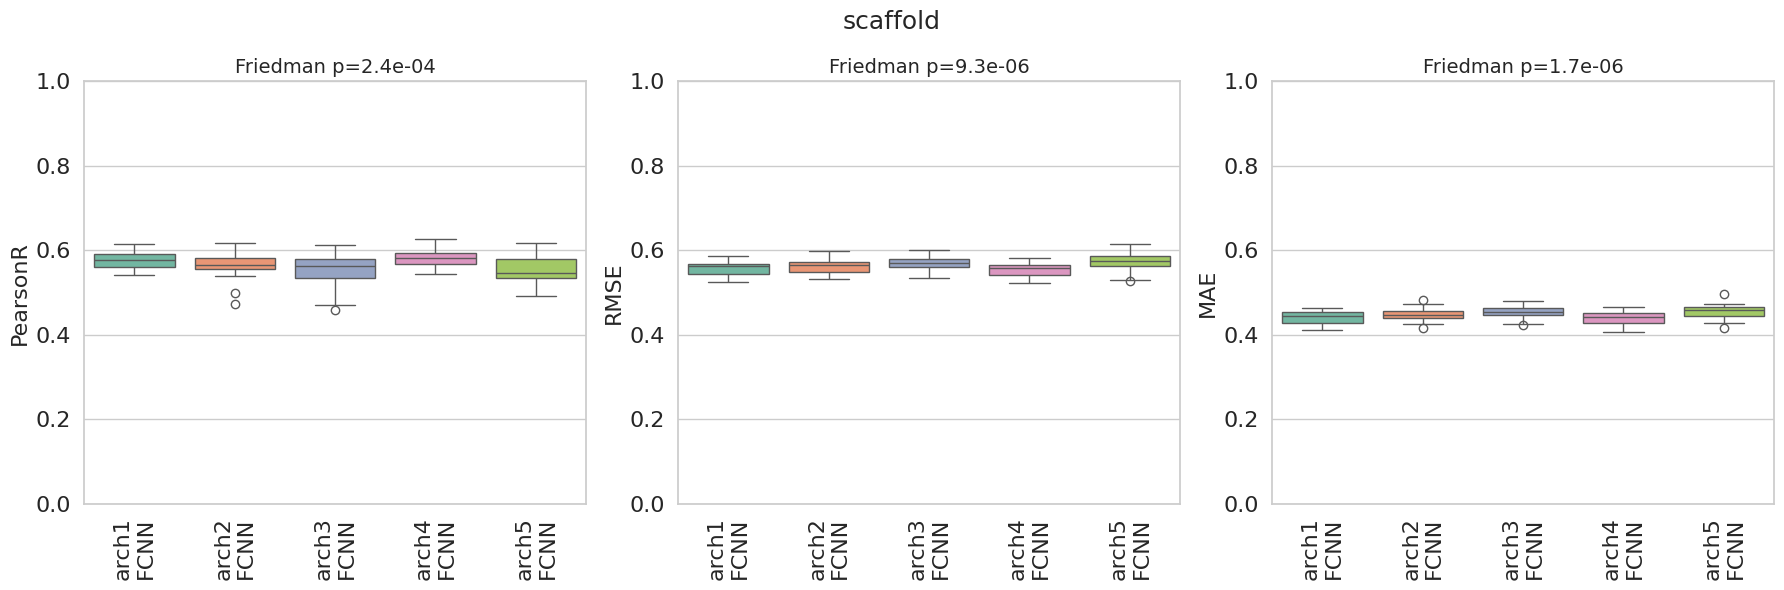

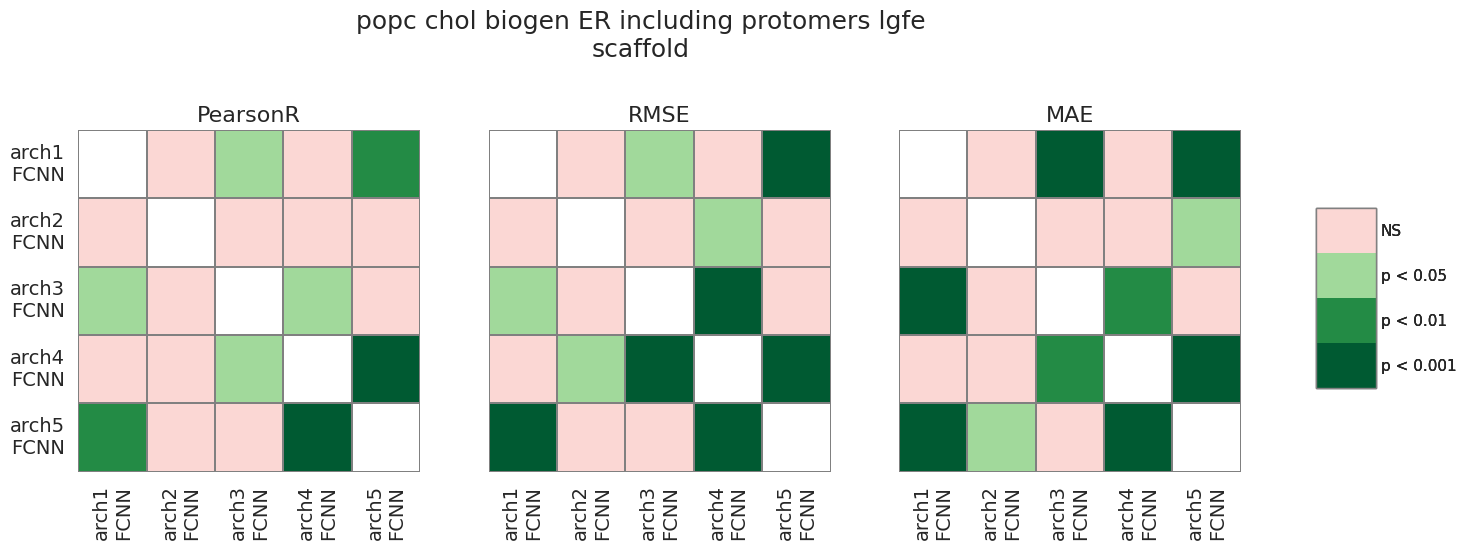

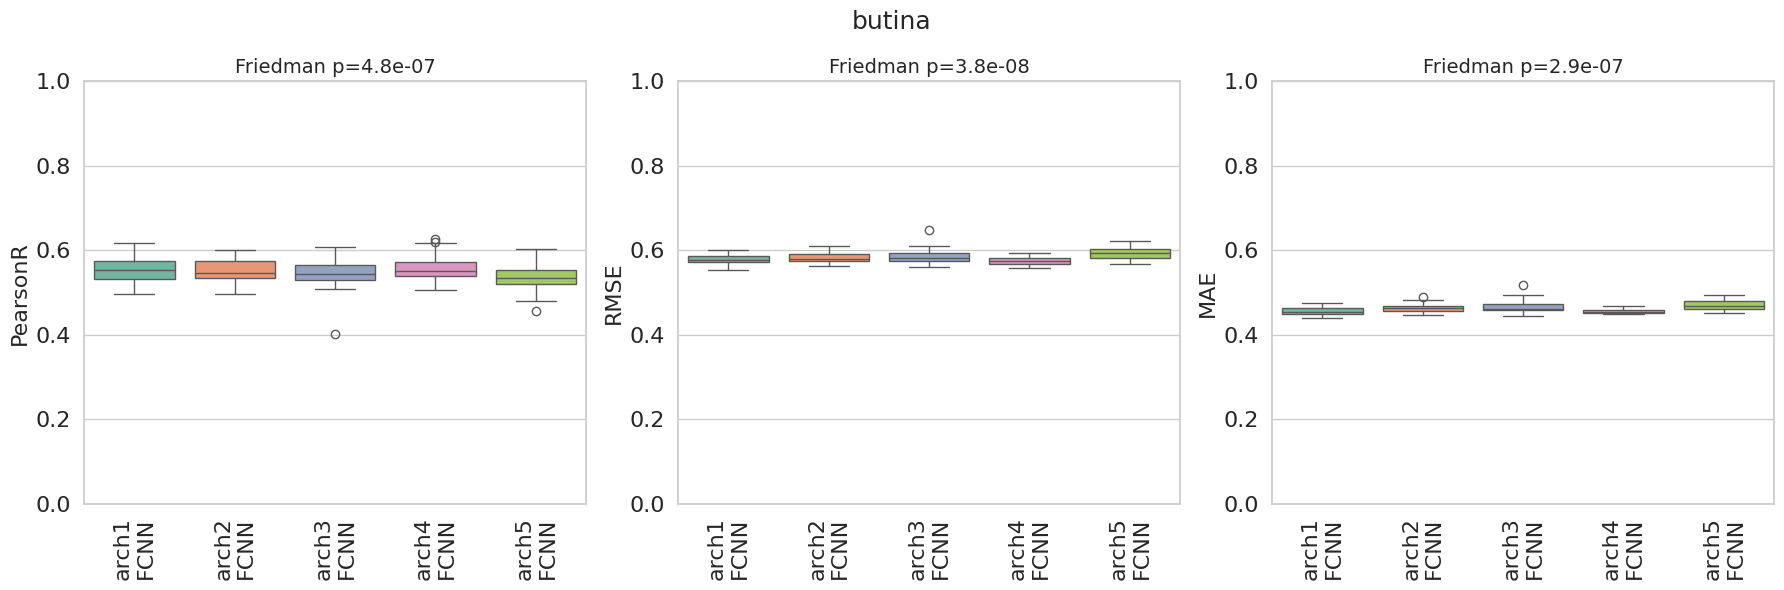

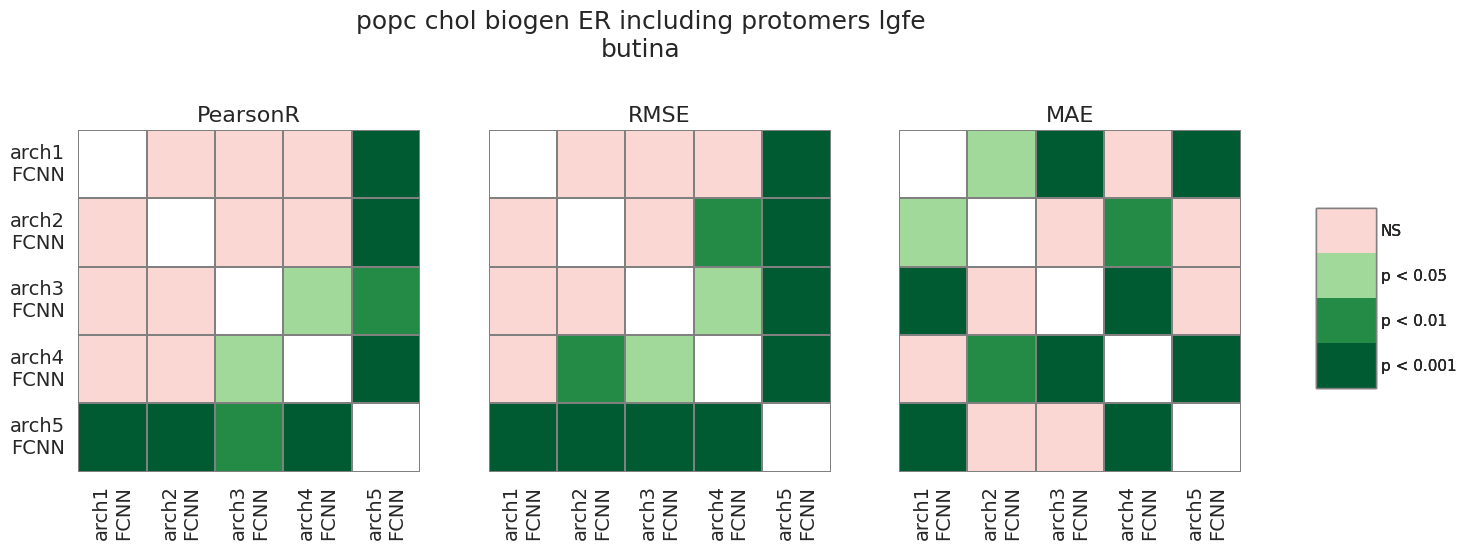

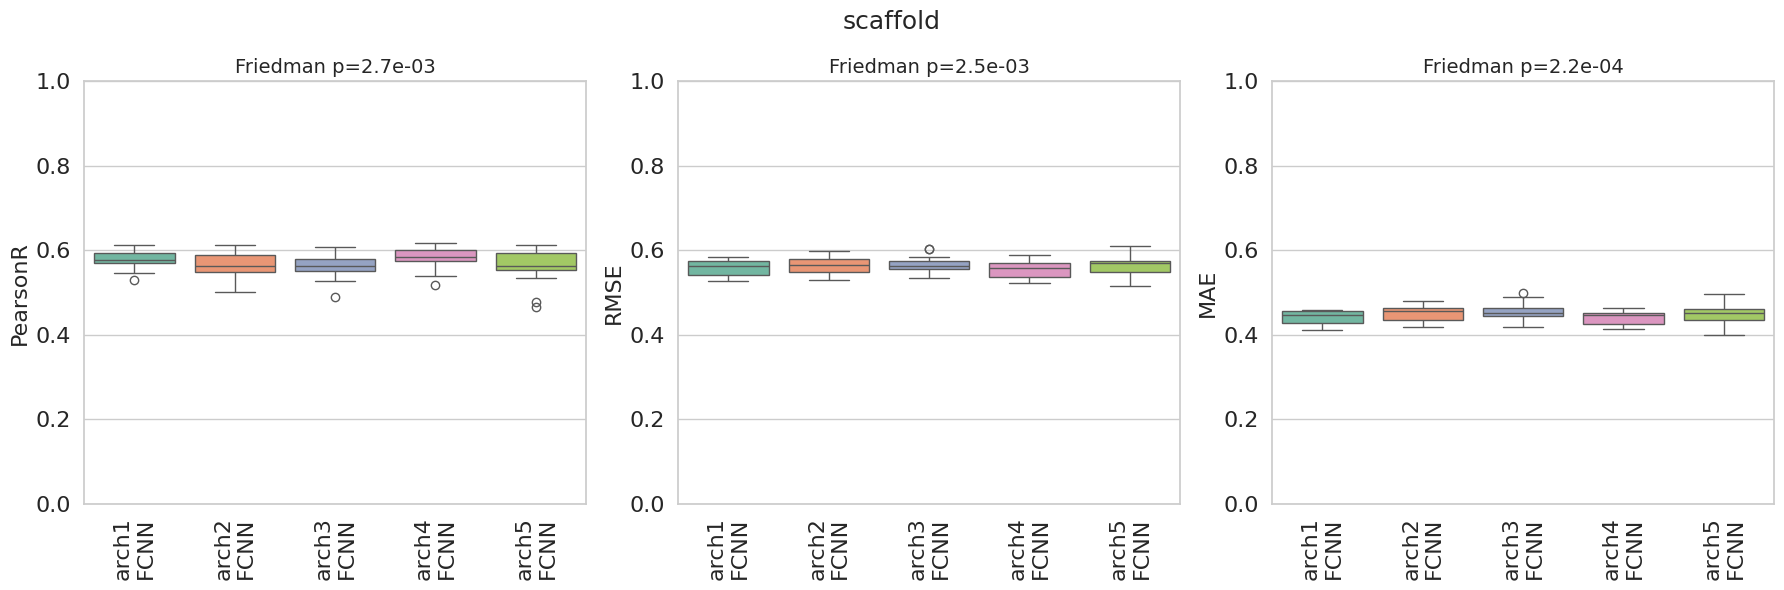

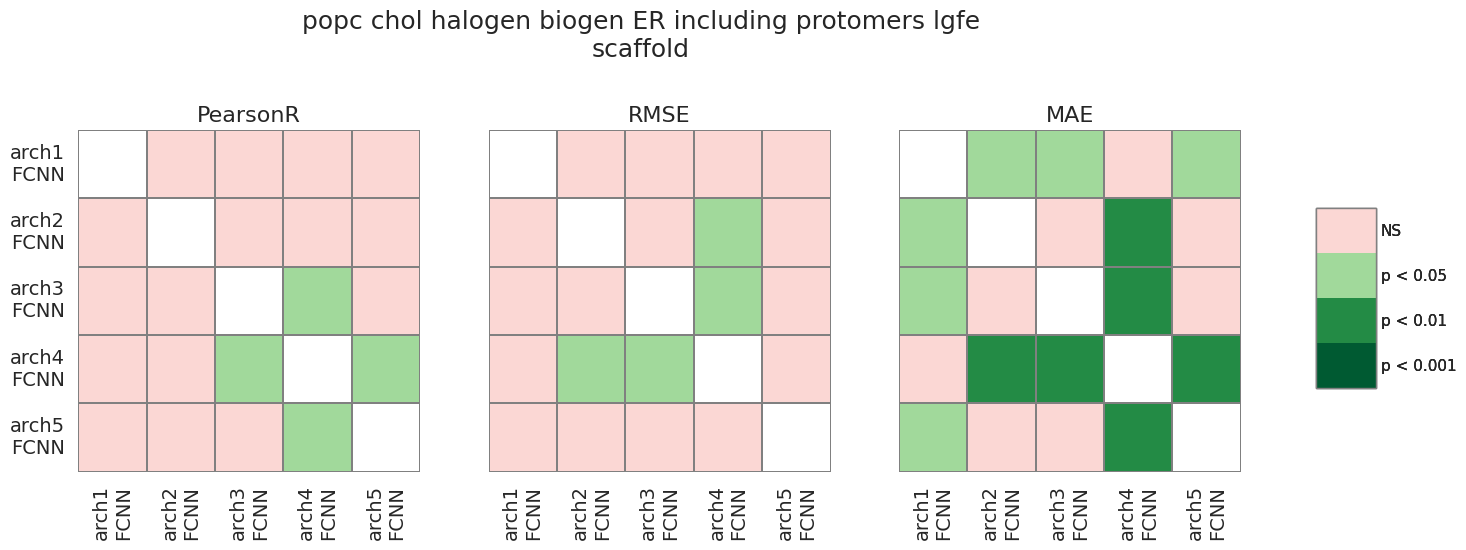

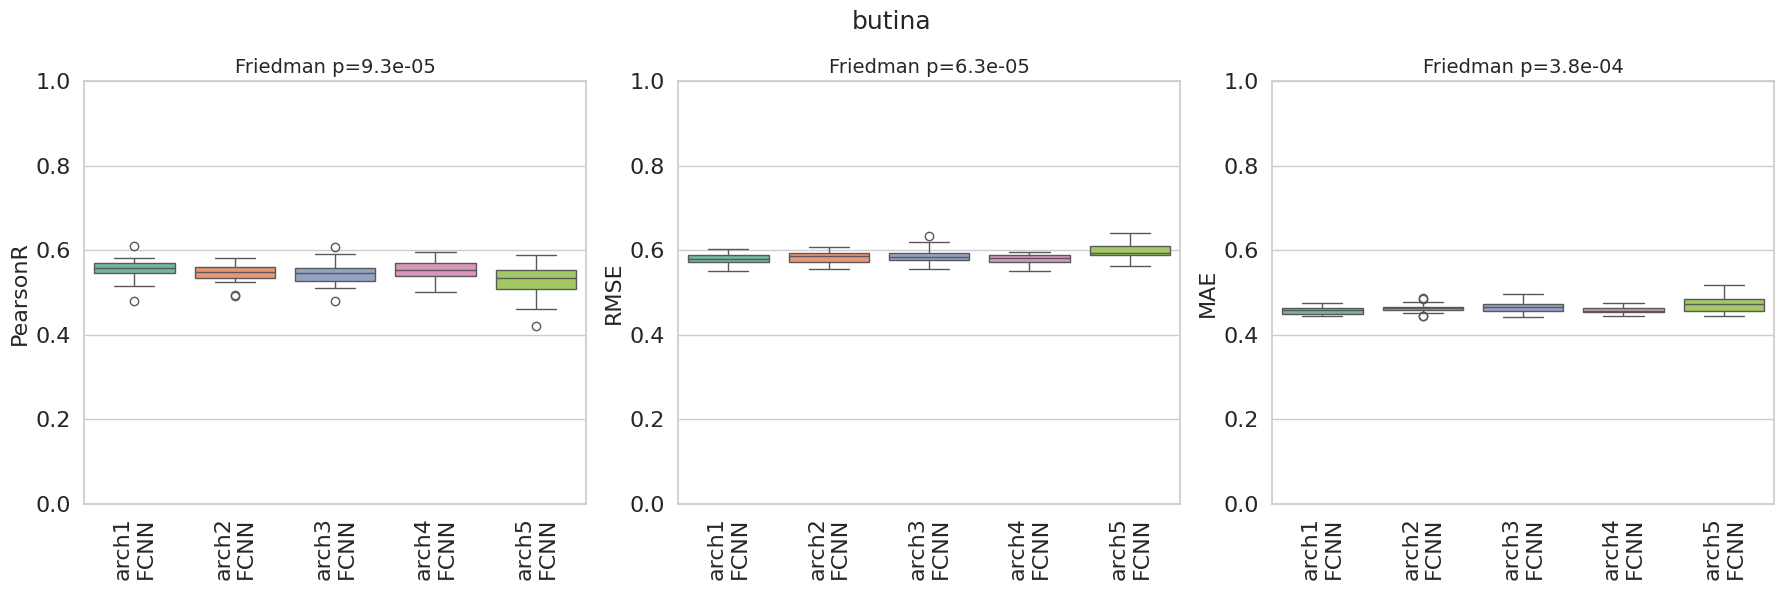

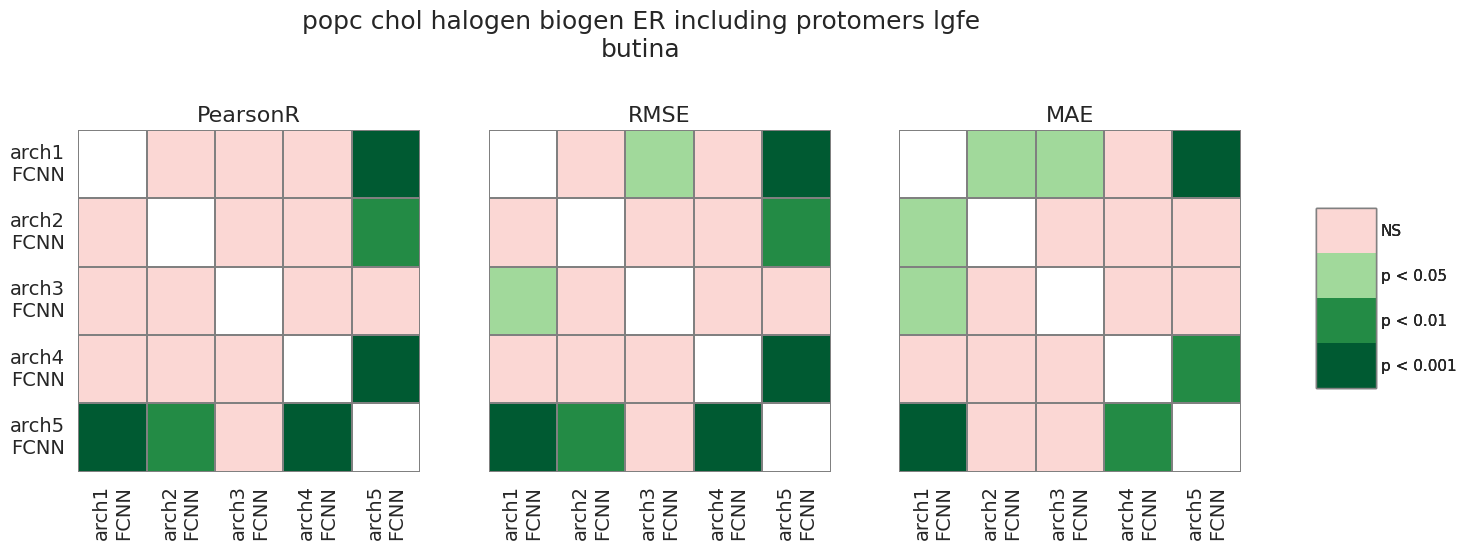

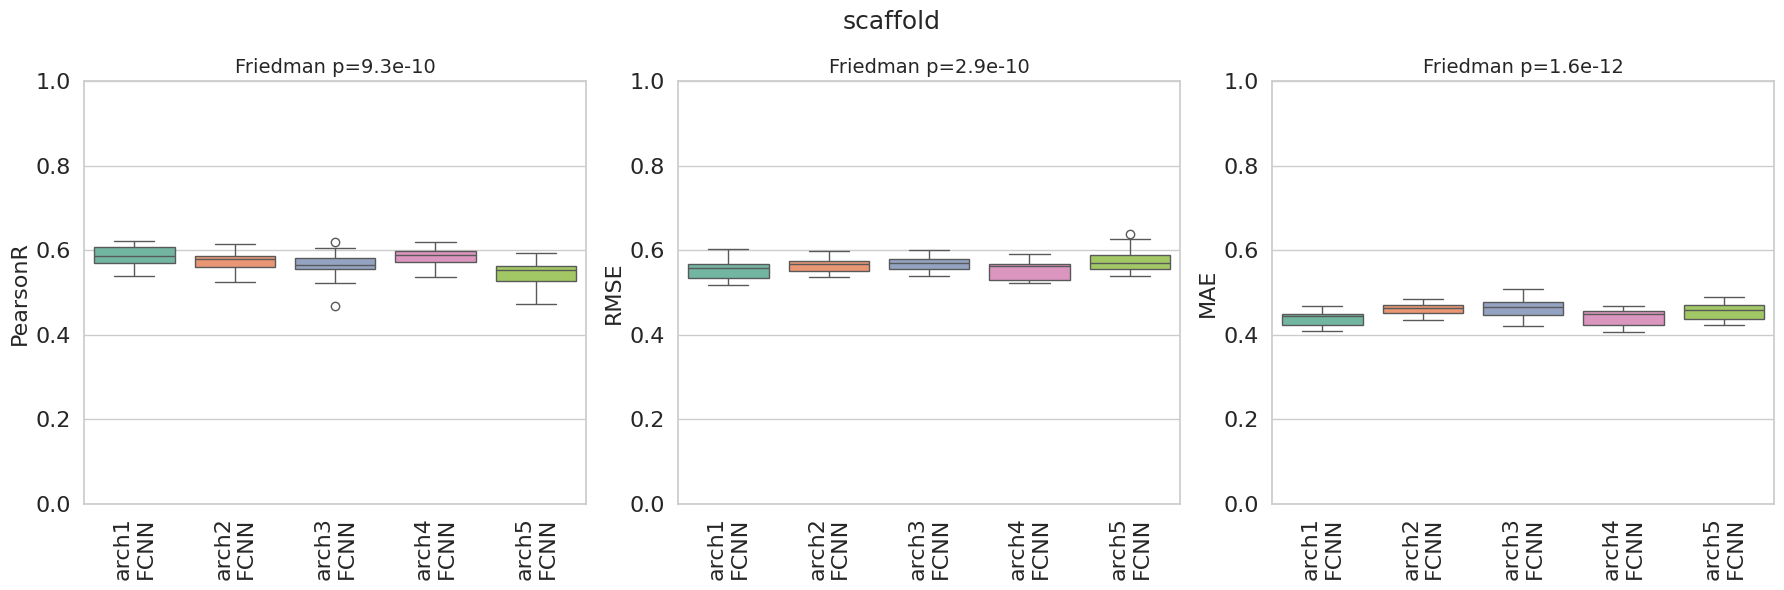

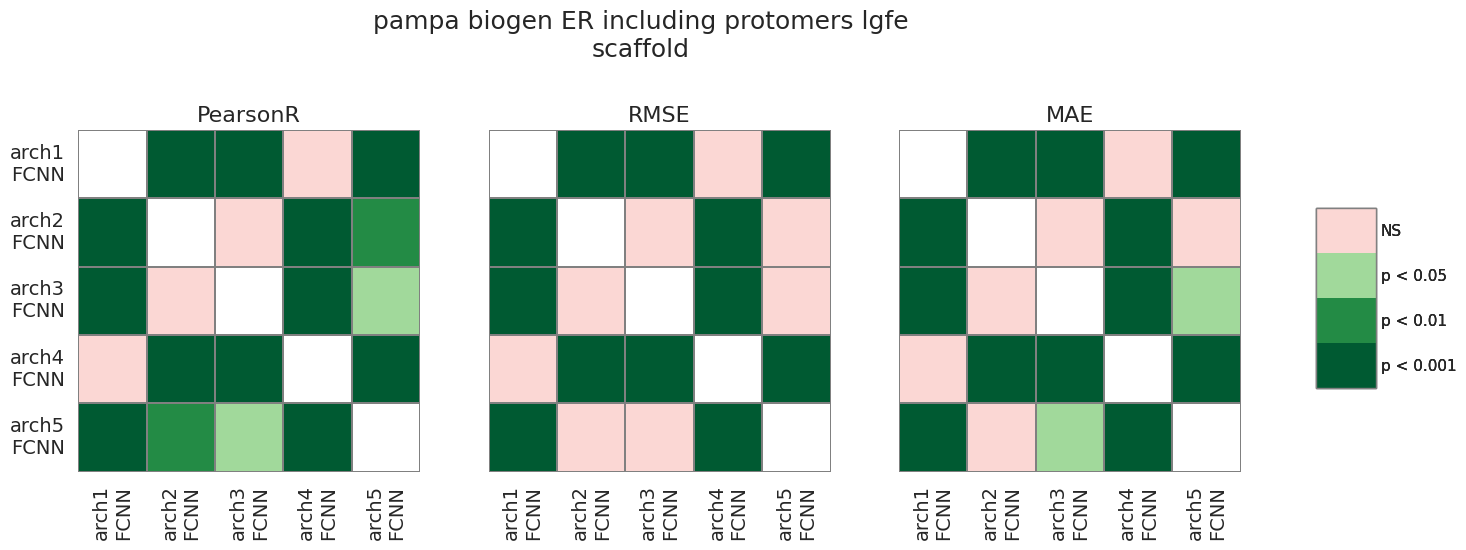

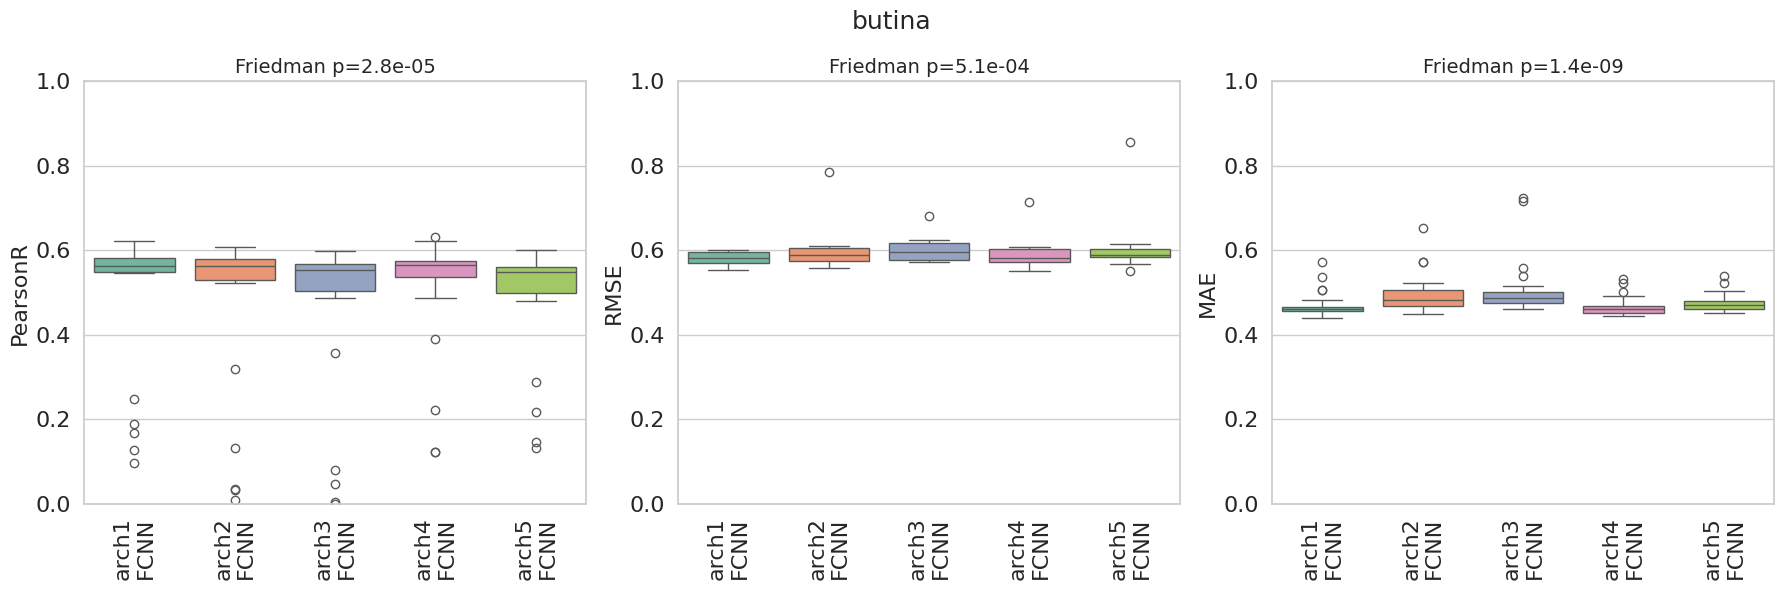

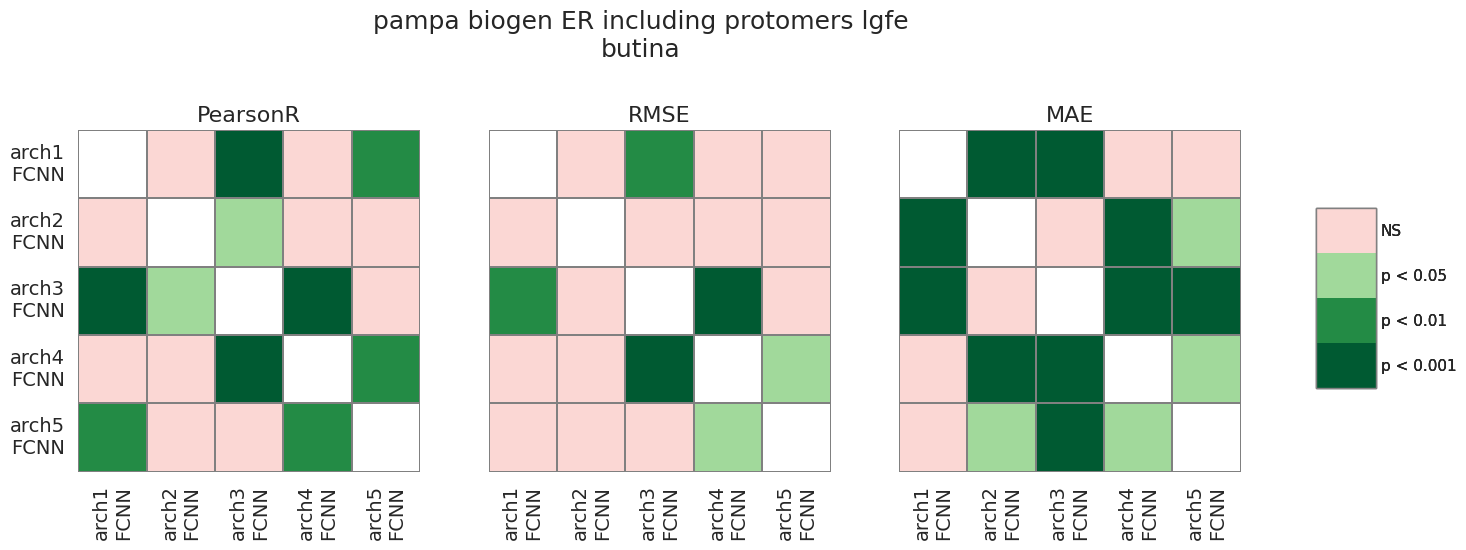

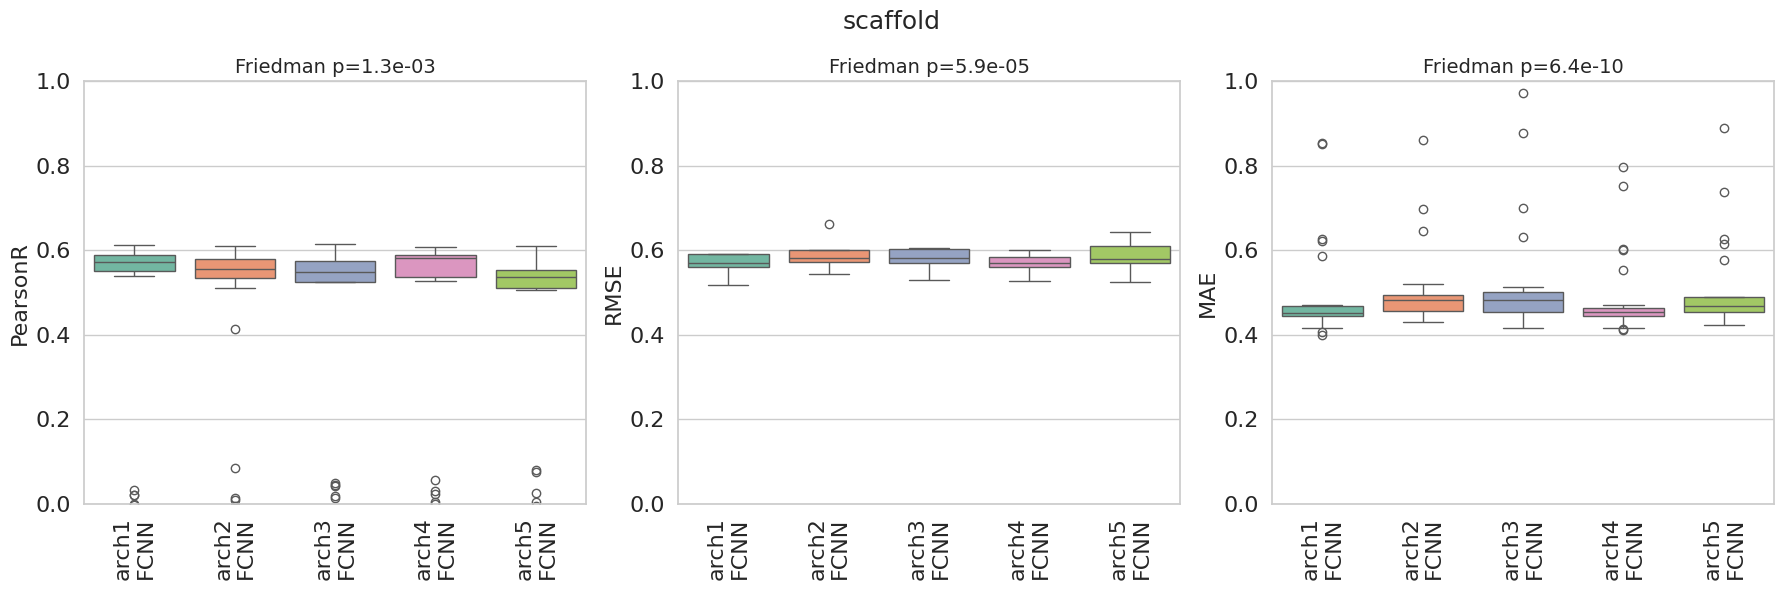

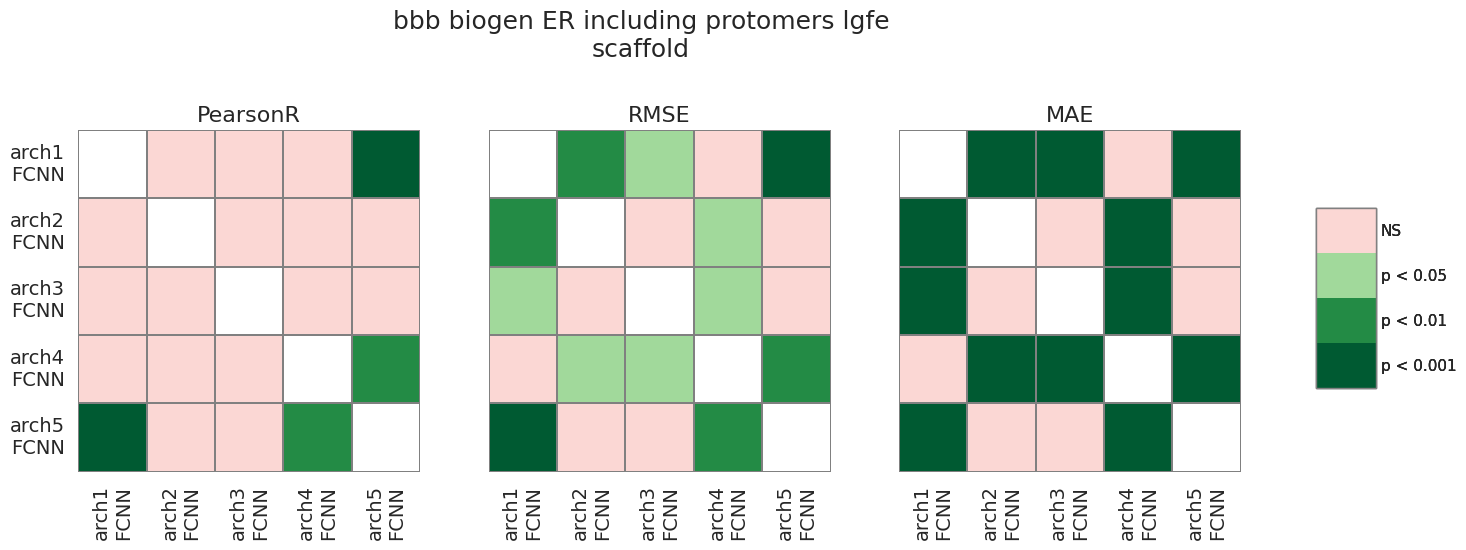

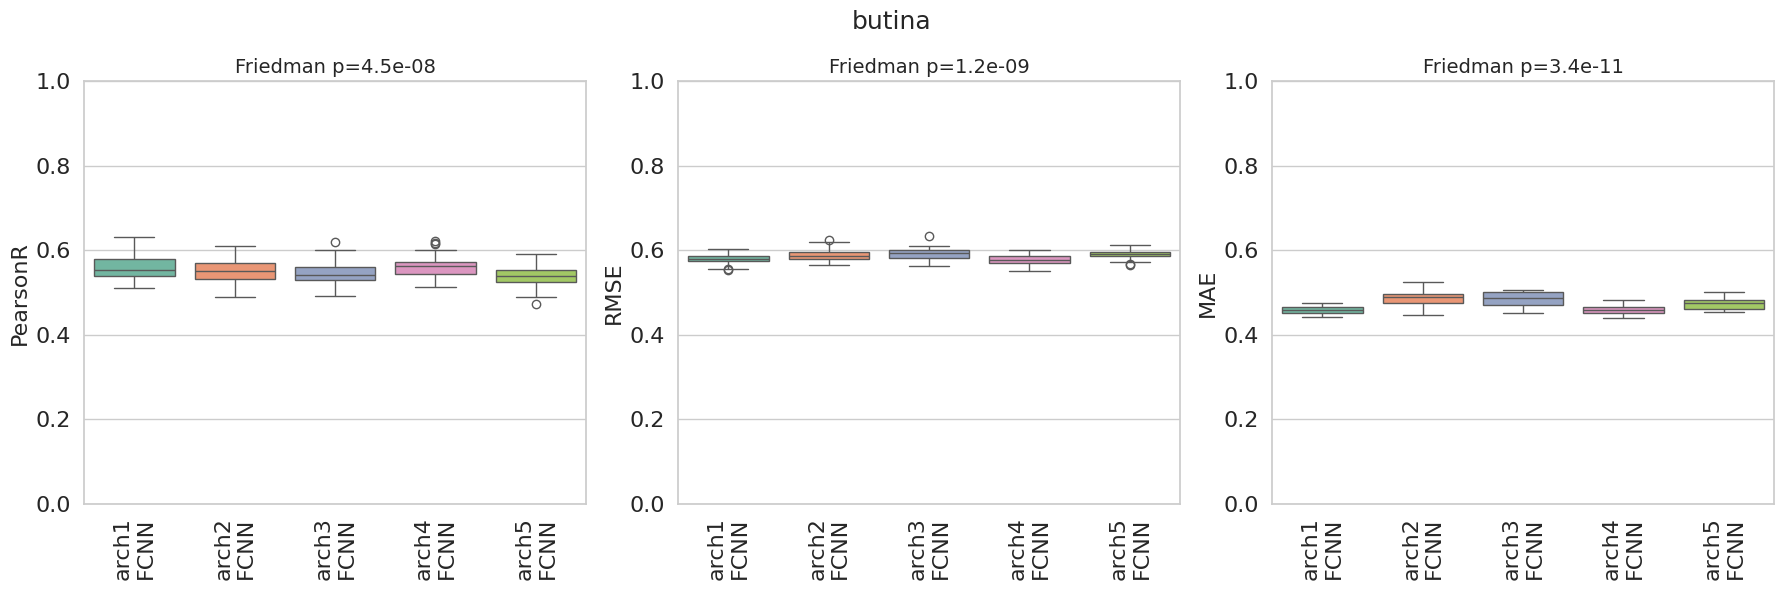

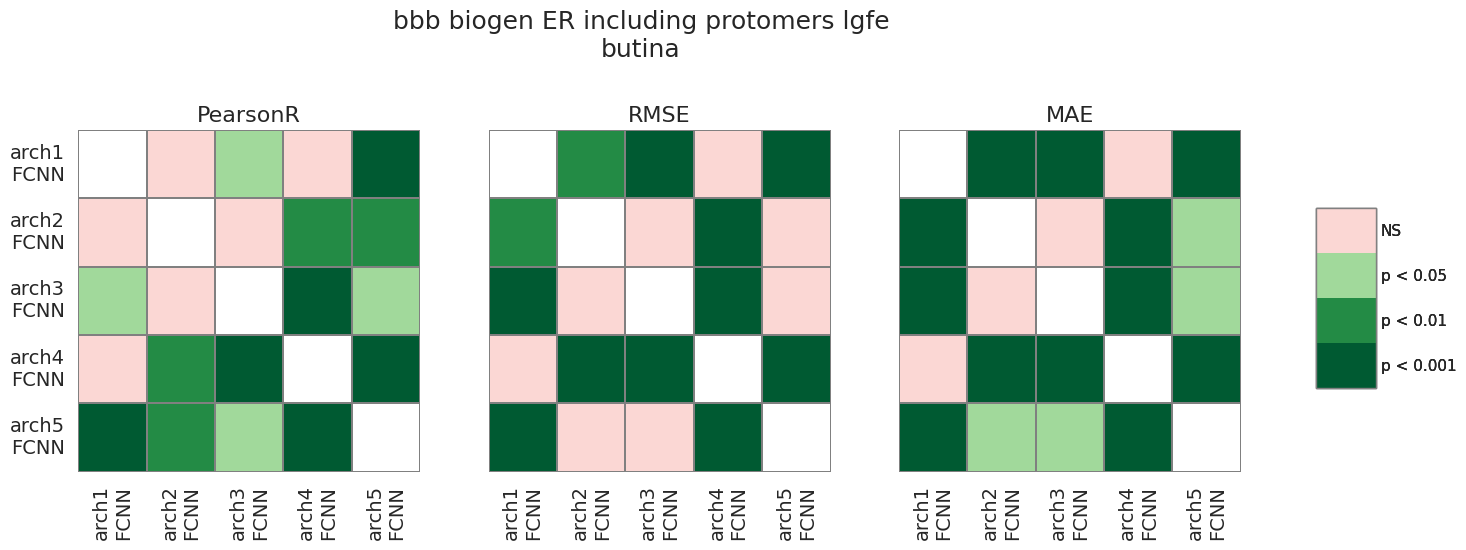

In [5]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] 
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/across_fcnn_archs_ER_protomers")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/across_fcnn_archs_ER_protomers")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER_protomers/across_fcnn_archs_ER_protomers/Levene_variance_results.xlsx"
)

#### 1. B. FCNN Arch 1 seems like a good choice for further comparison since it has relatively better performace metrics and lower variablility compared to other architectures tested. 

In [6]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_*.csv"]]

      split       metric  levene_pvalue  max_over_min
0    butina           R2       0.021982  1.900947e+04
1    butina         RMSE       0.005454  2.789988e+03
2    butina          MAE       0.038274  1.135652e+01
3    butina     PearsonR       0.002881  4.194200e+01
4    butina  SpearmanRho       0.800163  1.614460e+00
5  scaffold           R2       0.023899  1.281913e+07
6  scaffold         RMSE       0.004361  3.651113e+04
7  scaffold          MAE       0.003890  6.318080e+01
8  scaffold     PearsonR       0.001064  1.367050e+02
9  scaffold  SpearmanRho       0.188576  1.827476e+00


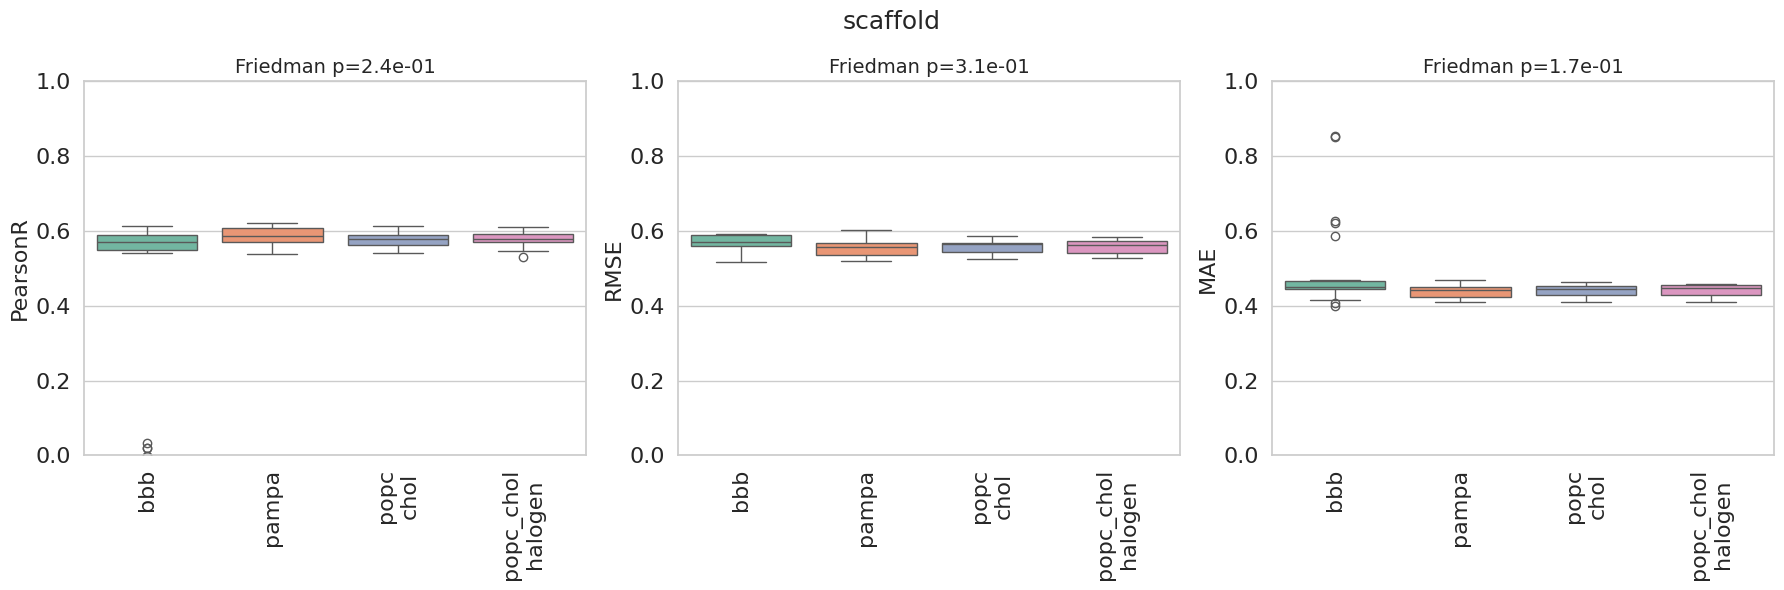

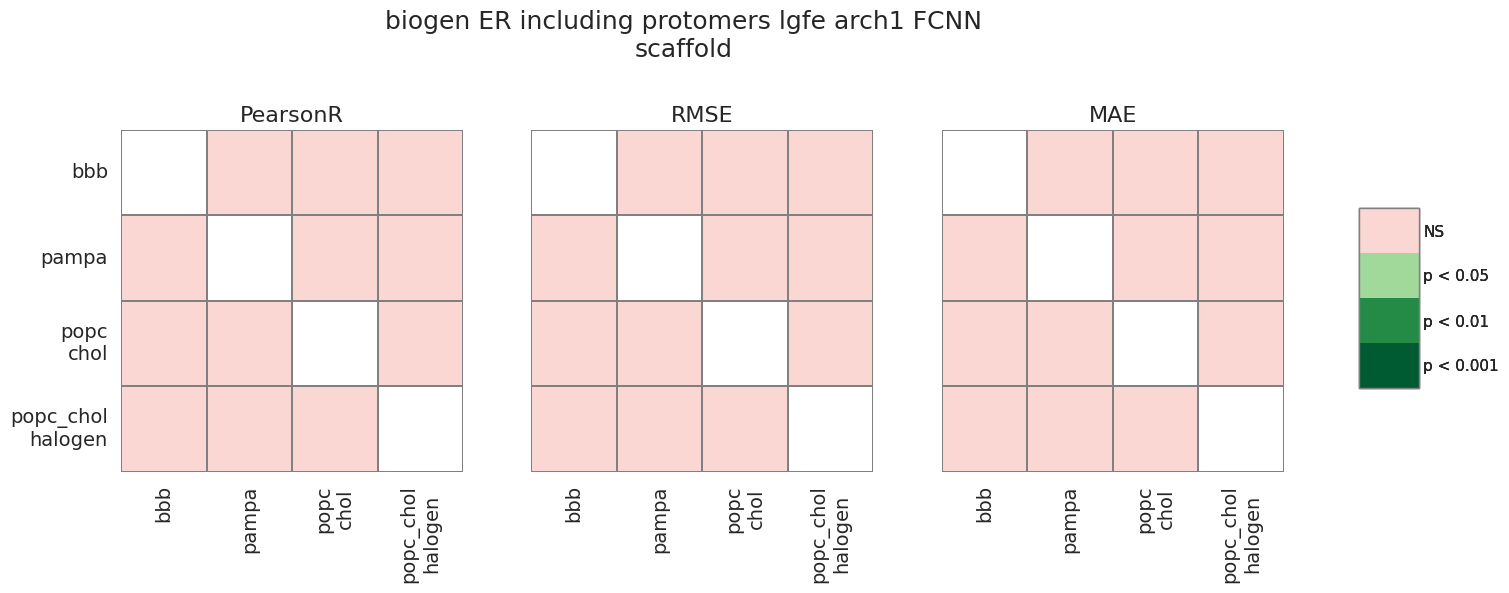

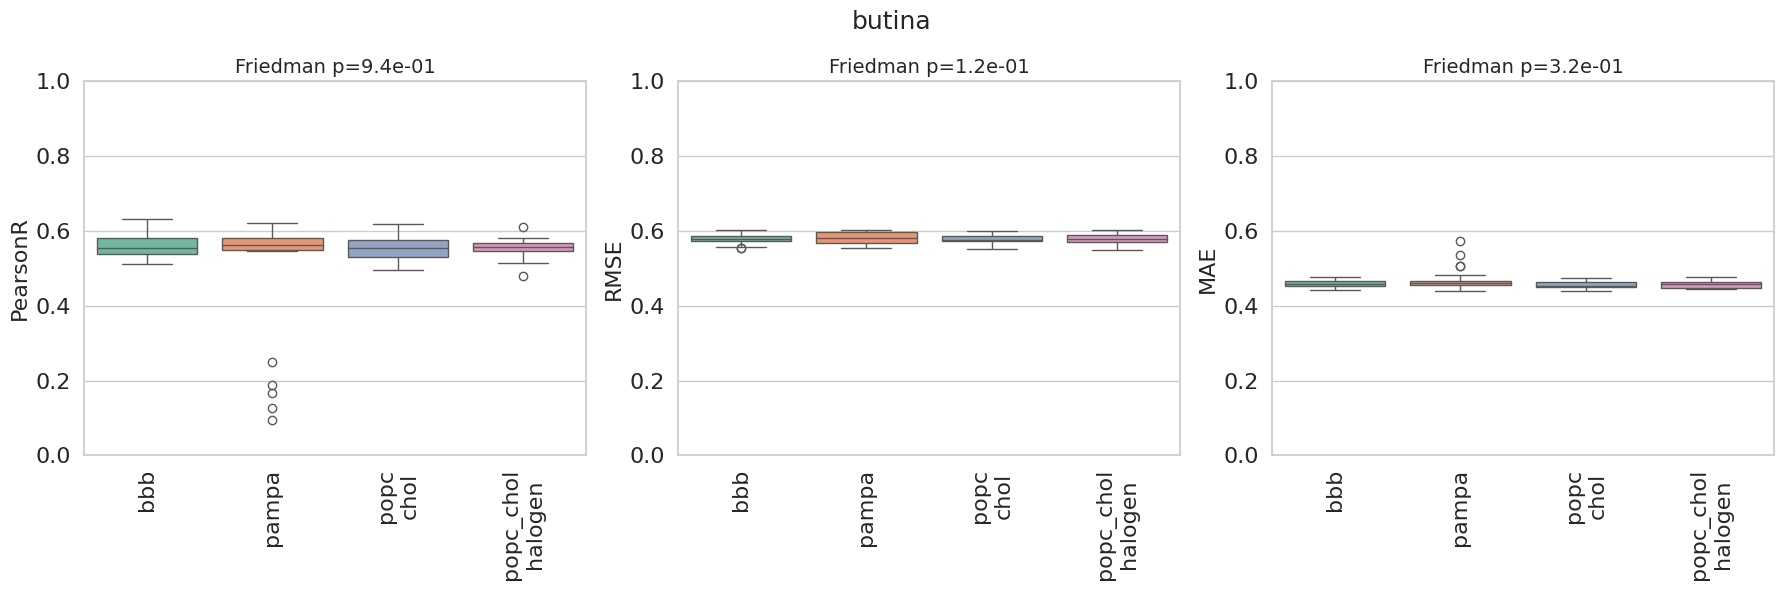

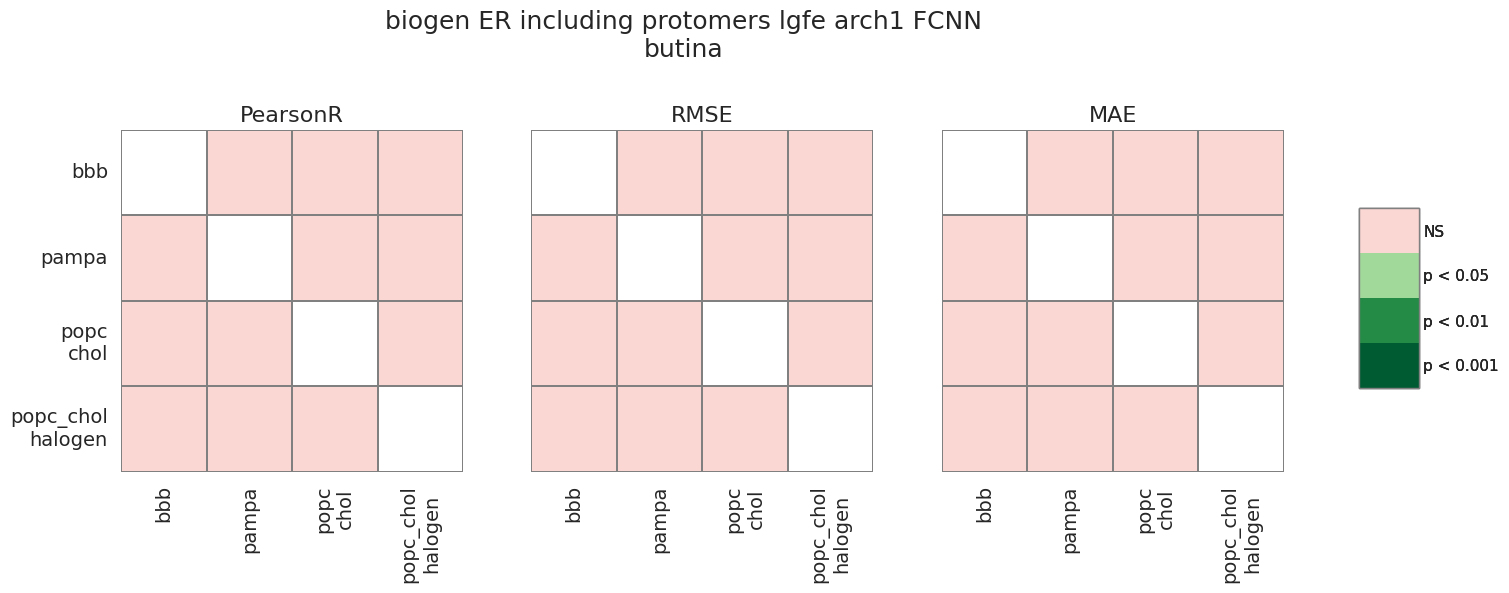

In [7]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] # , 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/fcnn1_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe_arch1_FCNN")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/fcnn1_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe_arch1_FCNN")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER_protomers/fcnn1_across_membs_ER_protomers/Levene_variance_results.xlsx"
)

TDLR: Both PAMPA and BBB models are better than simple POPC-CHOL models in terms of FCNN method

### 2. LightGBM

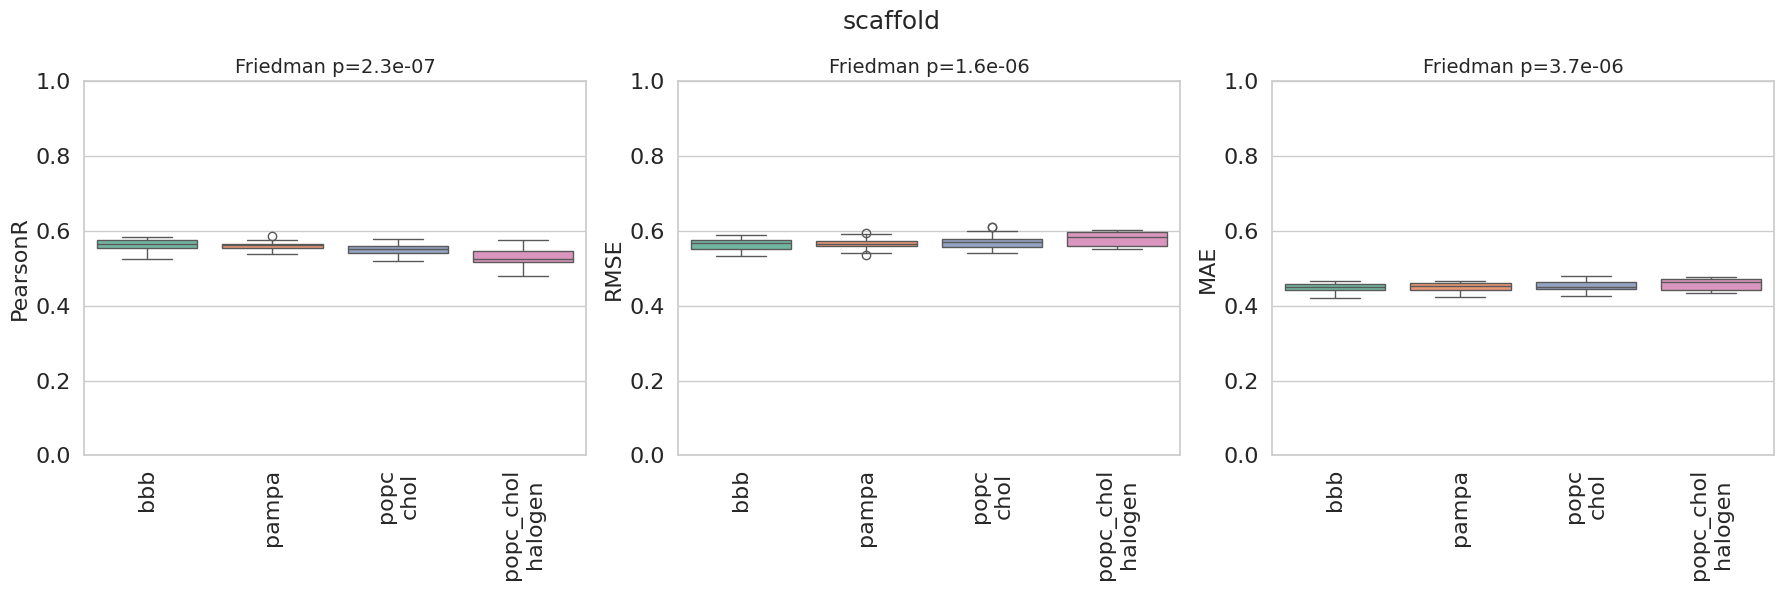

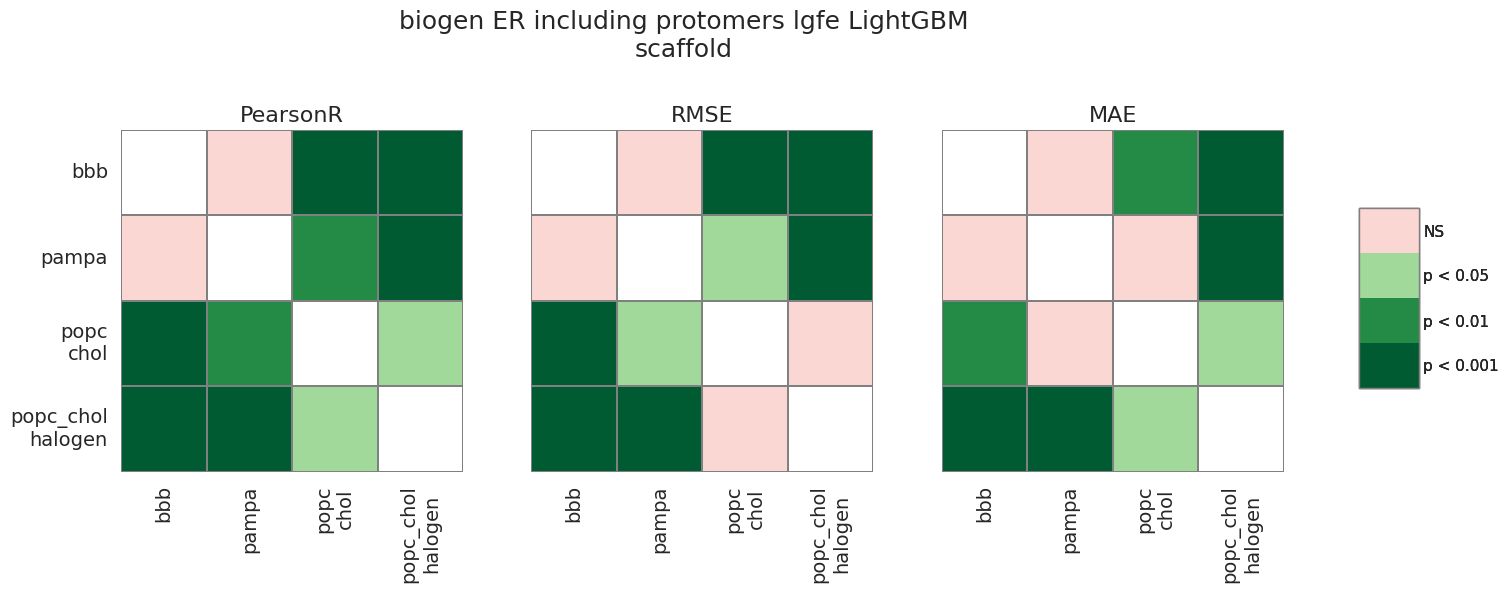

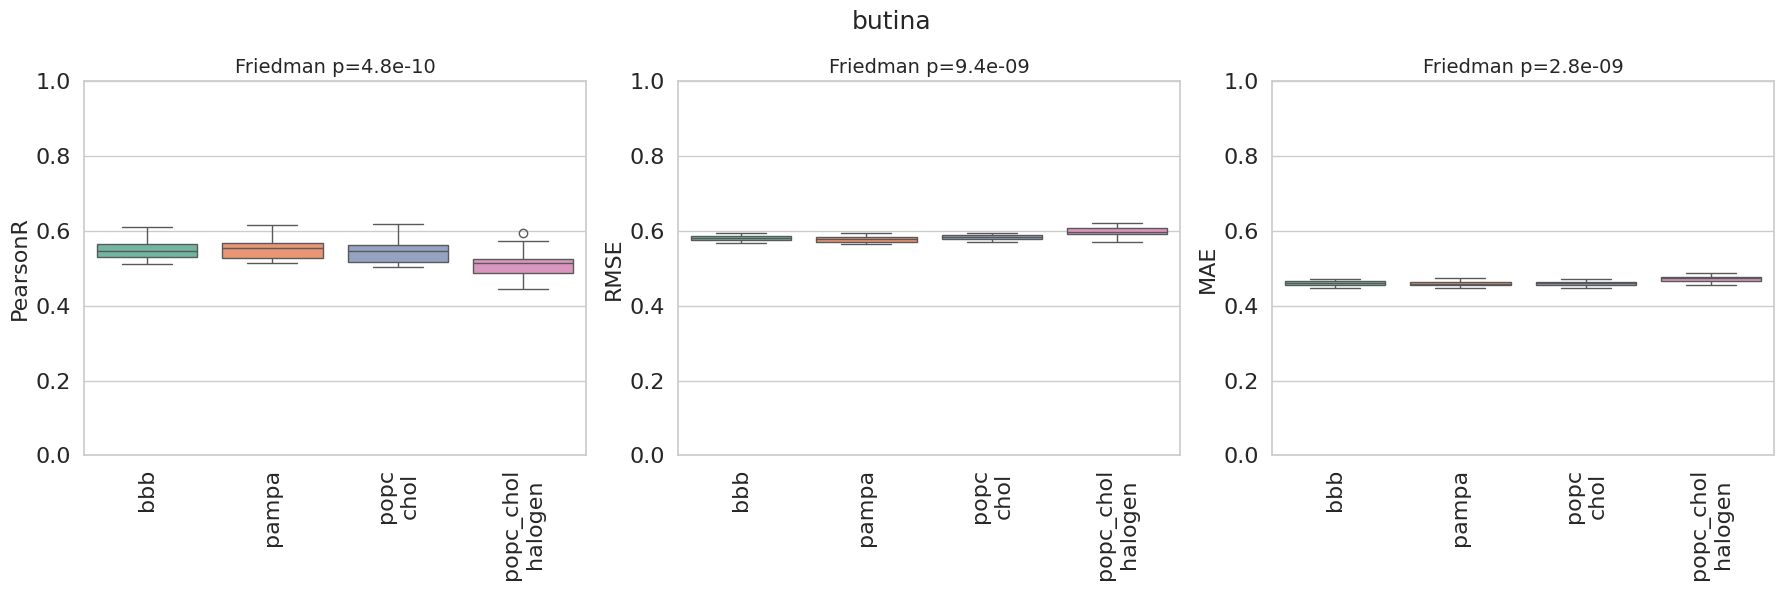

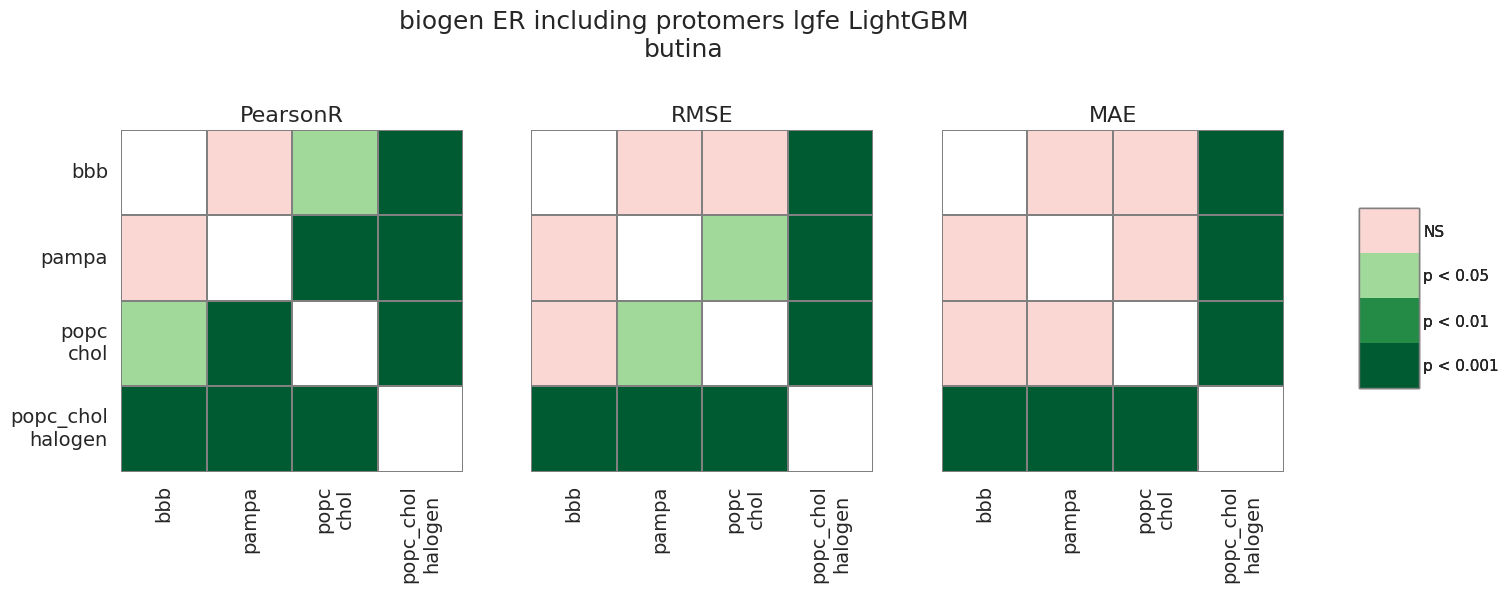

In [8]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] # , 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/lgbm_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe_LightGBM")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/lgbm_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe_LightGBM")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER_protomers/lgbm_across_membs_ER_protomers/Levene_variance_results.xlsx"
)

TDLR : Similar to FCNN, BBB and PAMPA models are better than POPC ones. Interestingly depending on the splitting strategy, there is a significant difference in performance between halogen maps and standard maps

evaluation_*.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.496976      1.726546
1     butina         RMSE       0.704383      1.741515
2     butina          MAE       0.288564      2.484141
3     butina     PearsonR       0.656691      1.502234
4     butina  SpearmanRho       0.713523      1.388333
5     random           R2       0.009591      3.839673
6     random         RMSE       0.234286      2.469075
7     random          MAE       0.070969      2.681147
8     random     PearsonR       0.006410      3.765509
9     random  SpearmanRho       0.501236      1.819732
10  scaffold           R2       0.916341      1.258282
11  scaffold         RMSE       0.524111      1.624007
12  scaffold          MAE       0.910686      1.566279
13  scaffold     PearsonR       0.948268      1.266179
14  scaffold  SpearmanRho       0.759775      1.596981


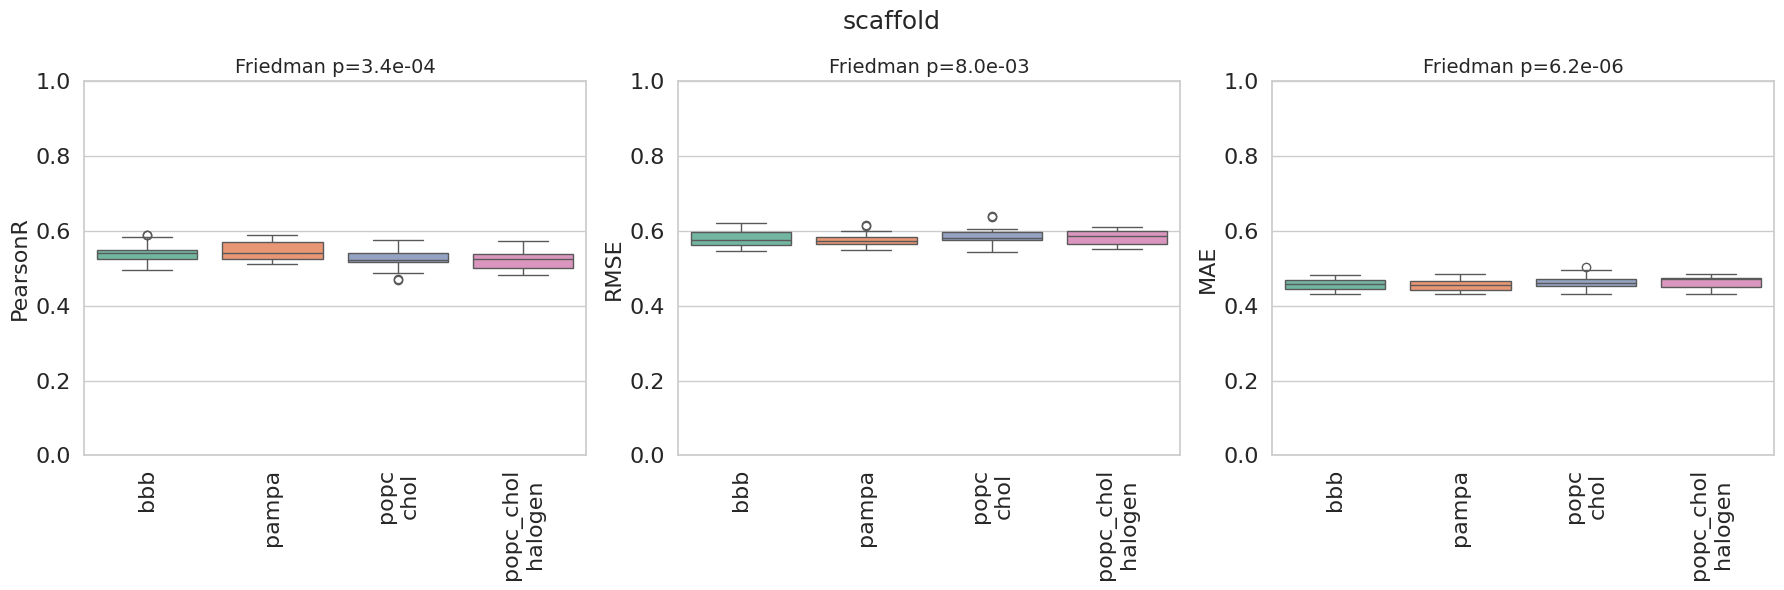

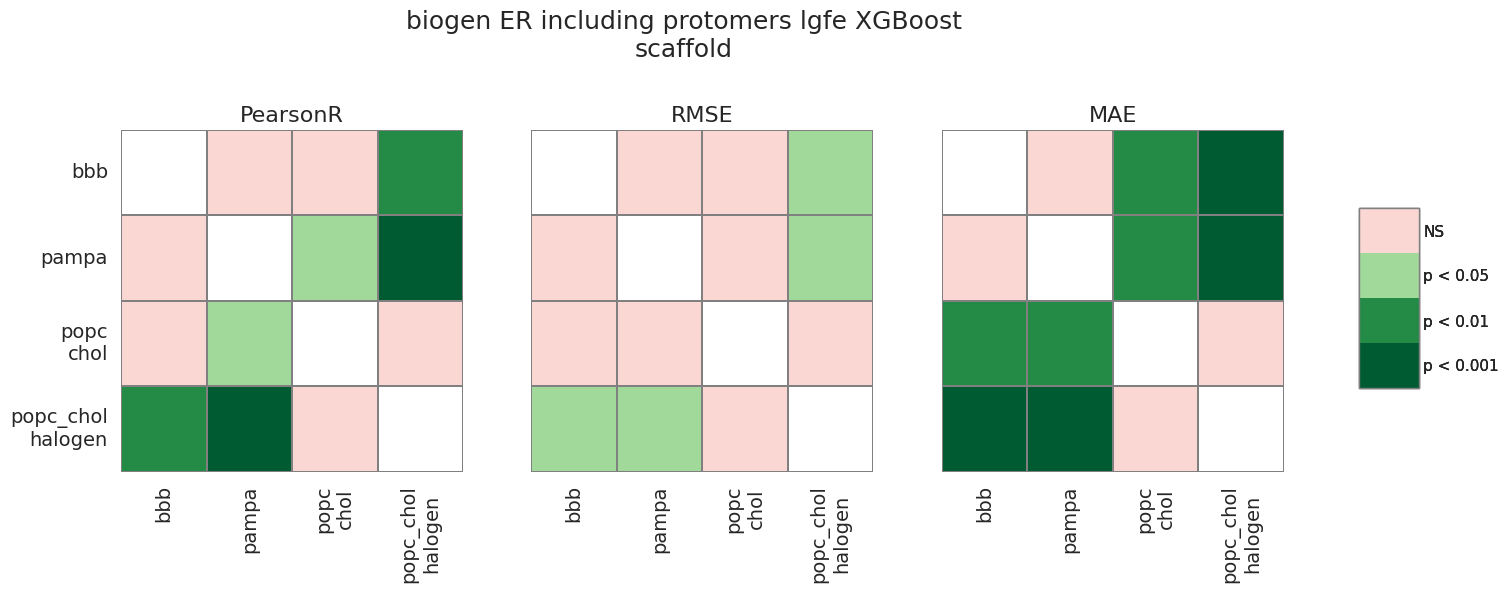

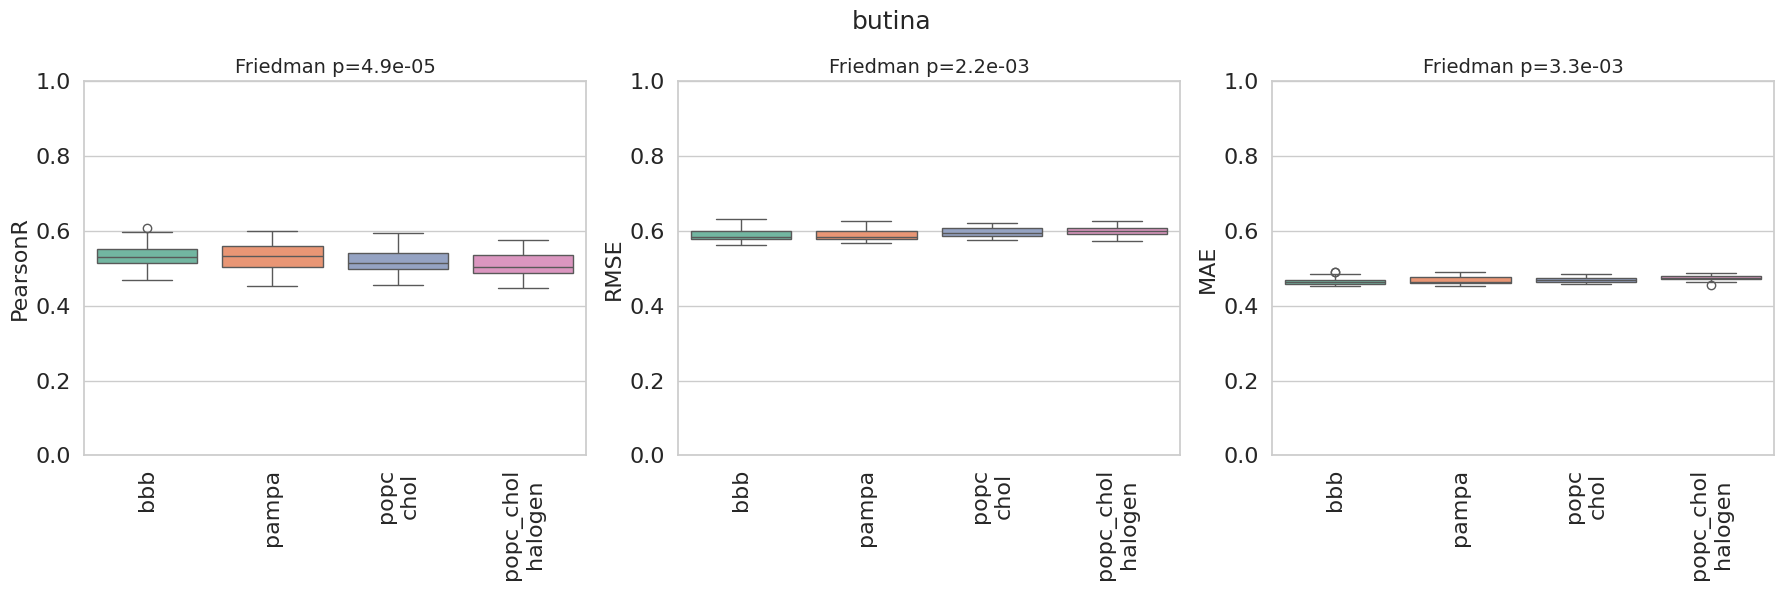

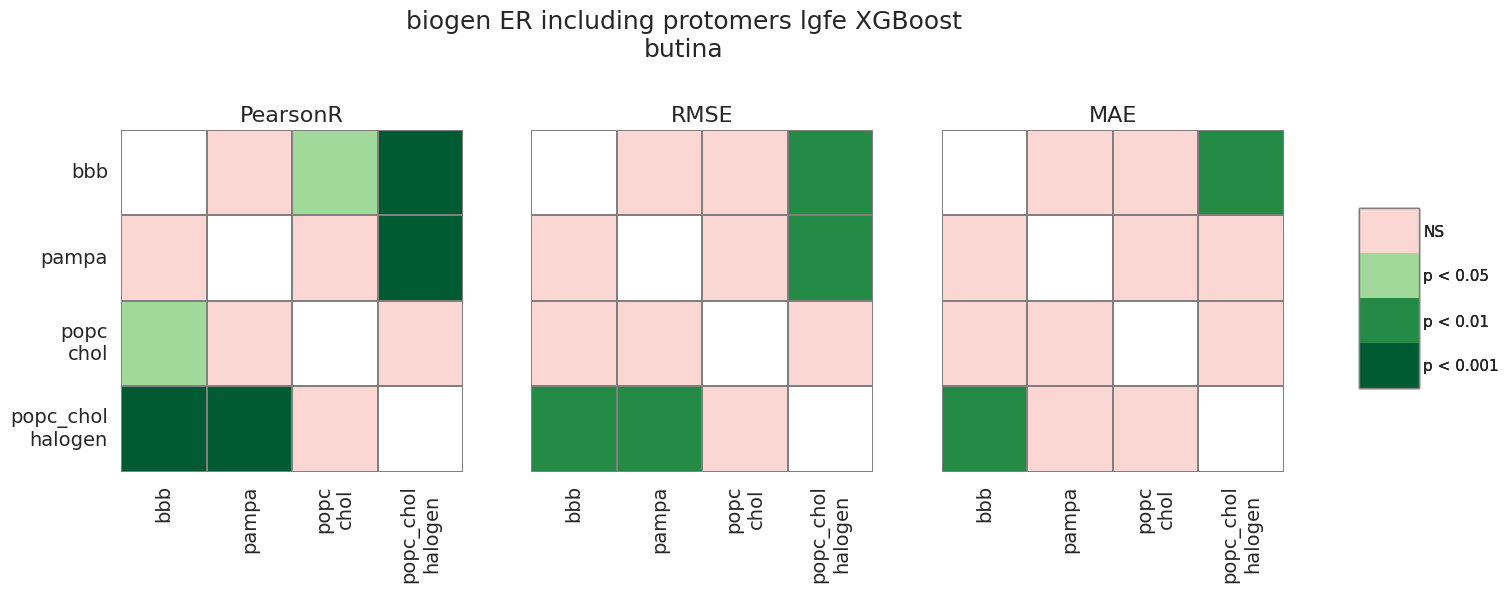

In [9]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] # , 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/xgb_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe_XGBoost")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/xgb_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe_XGBoost")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER_protomers/xgb_across_membs_ER_protomers/Levene_variance_results.xlsx"
)

TDLR: Same story : Adding halogen maps does not really improve the performance significantly but often reduce it

### 4. How about FCNN vs ensemble learning models?

evaluation_bbb.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2   1.306867e-03  1.787857e+04
1     butina         RMSE   4.467533e-05  7.517460e+03
2     butina          MAE   2.587407e-03  2.410141e+01
3     butina     PearsonR   5.849847e-05  3.933050e+01
4     butina  SpearmanRho   2.765737e-01  2.315311e+00
5     random           R2   3.070103e-01  1.966058e+00
6     random         RMSE   7.797099e-01  1.638361e+00
7     random          MAE   2.715458e-01  1.990217e+00
8     random     PearsonR   1.659882e-01  2.172785e+00
9     random  SpearmanRho   7.182926e-01  1.965121e+00
10  scaffold           R2   1.445936e-03  2.886322e+07
11  scaffold         RMSE   2.790444e-05  4.095030e+04
12  scaffold          MAE   2.078863e-05  7.898927e+01
13  scaffold     PearsonR   5.710790e-07  3.482721e+02
14  scaffold  SpearmanRho   1.132139e-01  3.254624e+00


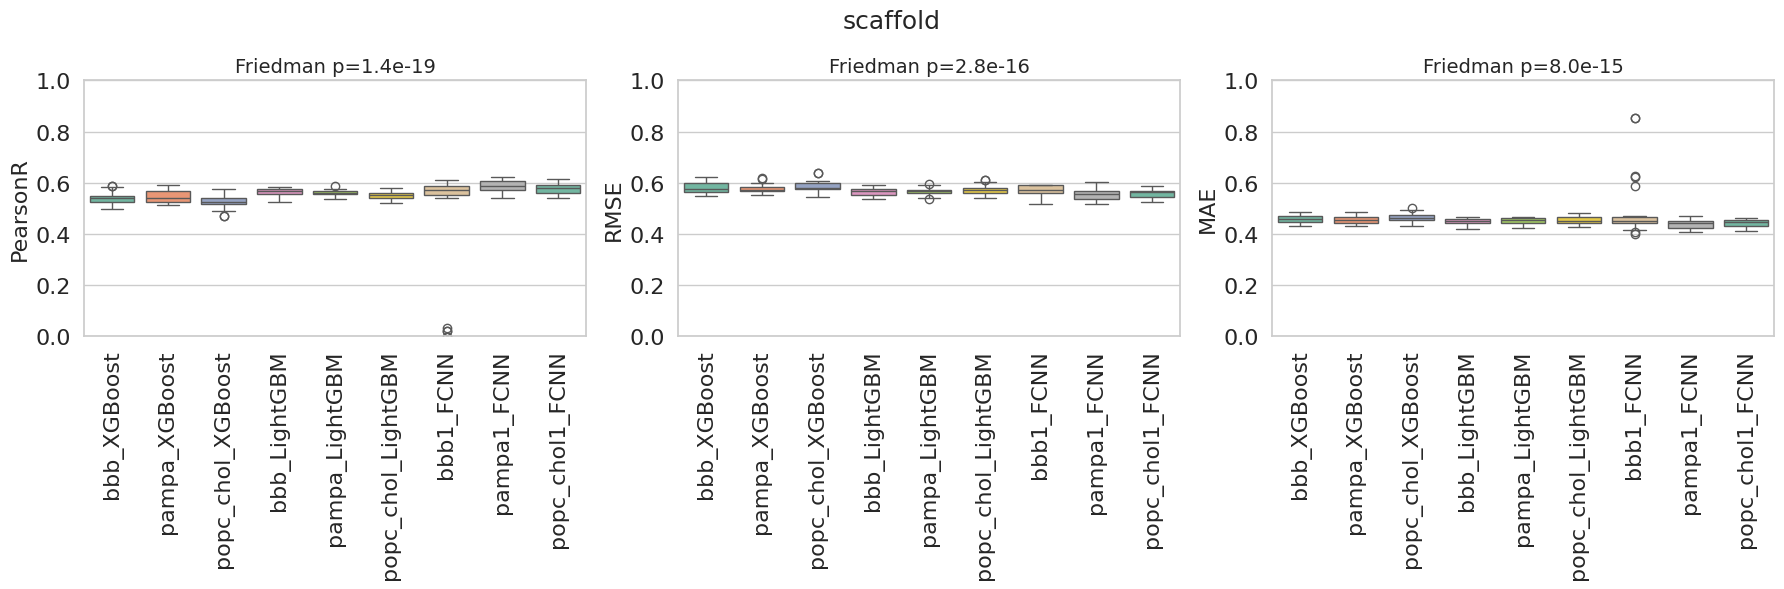

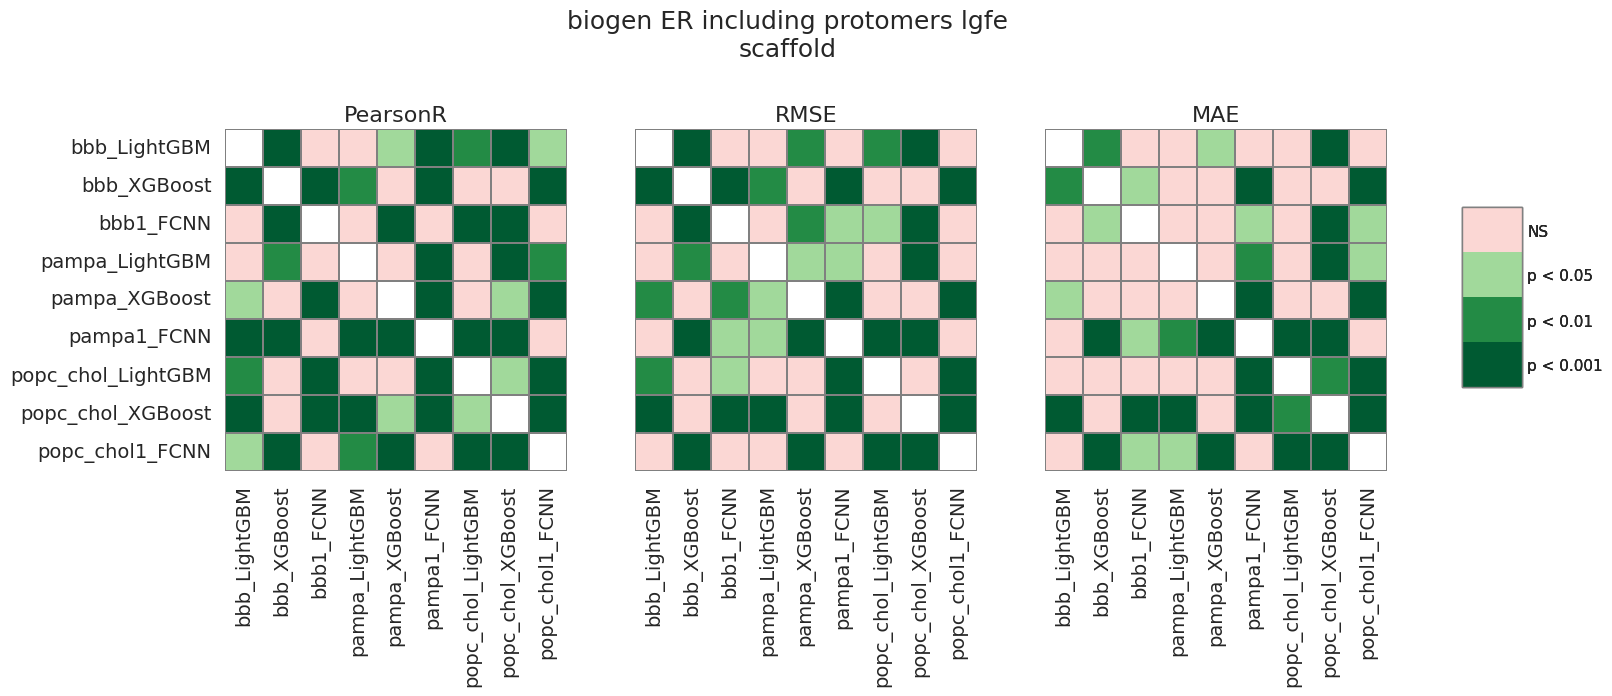

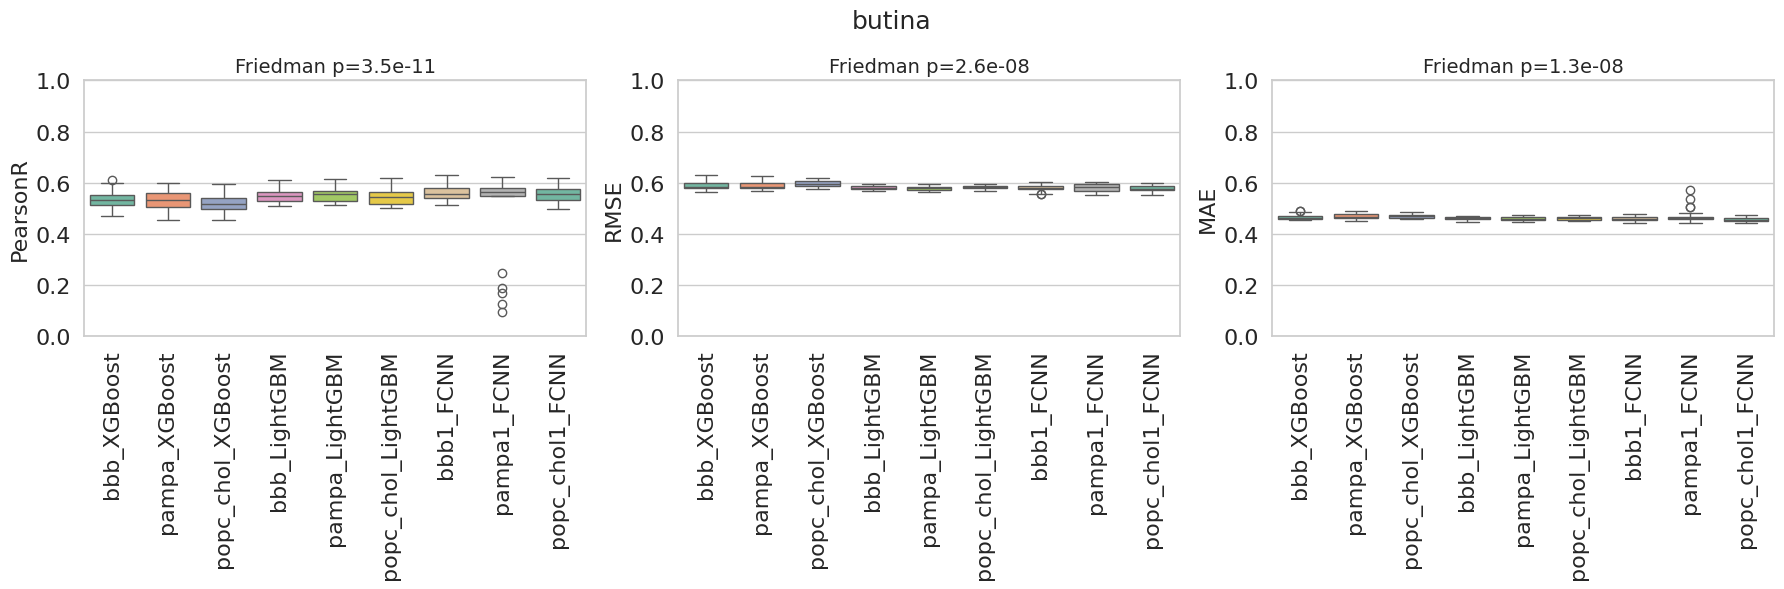

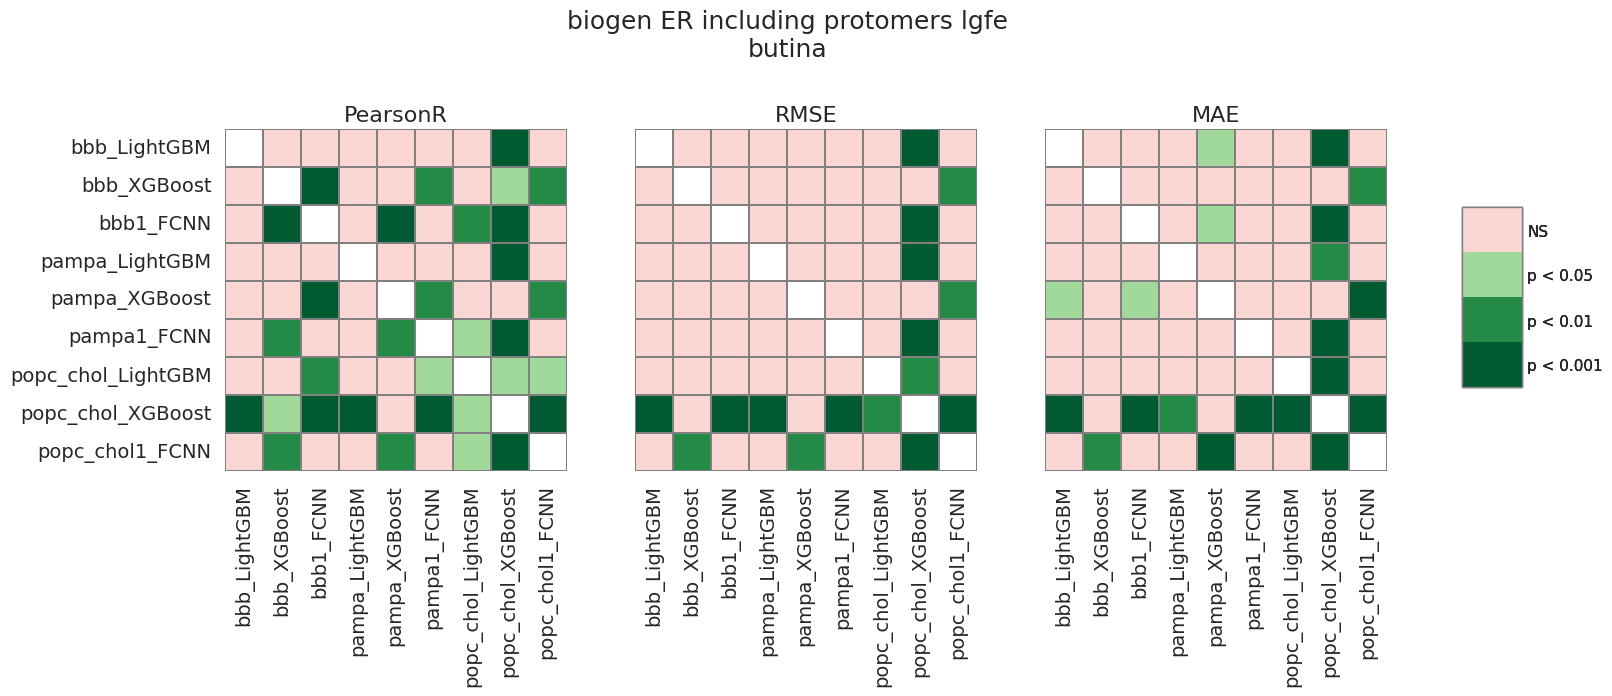

In [10]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_bbb.csv",
                   "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_pampa.csv",
                   "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_popc_chol.csv",
                  "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_bbb.csv",
                   "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_pampa.csv",
                   "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_popc_chol.csv",
                  "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_bbb.csv",
                   "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_pampa.csv",
                   "../ml-modeling-ER_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_popc_chol.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] #, 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/allmodels_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe", line_breaks=False)
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER_protomers/allmodels_across_membs_ER_protomers", common_prefix="-biogen-ER-including-protomers_lgfe", line_breaks=False)

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER_protomers/allmodels_across_membs_ER_protomers/Levene_variance_results.xlsx"
)